# NYC Yellow Taxi Trips — Statistical Analysis & Demand Forecast


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import normaltest, anderson, levene, bartlett, jarque_bera
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")


## Configuration

In [2]:
# --- Update this path for your environment ---
DATA_PATH = r"E:\sagar material\yellow_trips_final.csv"

ALPHA = 0.05
SEED = 42
np.random.seed(SEED)

# Standard TLC payment_type codes, for readable labels in outputs/plots
PAYMENT_LABELS = {1: "Credit Card", 2: "Cash", 3: "No Charge", 4: "Dispute", 5: "Unknown", 6: "Voided Trip"}


## Load & Prepare Data

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,pickup_dt,dropoff_dt,passenger_count,RatecodeID,trip_distance,PULocationID,pickup_borough,pickup_zone,DOLocationID,dropoff_borough,dropoff_zone,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,trip_month
0,2026-01-01 00:54:04,2026-01-01 00:59:37,1,1,0.97,239,Manhattan,Upper West Side South,238,Manhattan,Upper West Side North,1,7.2,3.66,0.0,15.86,2026-01
1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,1,0.90,163,Manhattan,Midtown North,162,Manhattan,Midtown East,2,7.9,0.00,0.0,13.65,2026-01
2,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1,1.40,43,Manhattan,Central Park,237,Manhattan,Upper East Side South,1,10.7,2.50,0.0,18.95,2026-01
3,2026-01-01 00:15:22,2026-01-01 00:58:10,4,1,5.58,142,Manhattan,Lincoln Square East,209,Manhattan,Seaport,1,38.7,11.11,0.0,55.56,2026-01
4,2026-01-01 00:27:13,2026-01-01 00:40:43,0,1,2.16,88,Manhattan,Financial District South,144,Manhattan,Little Italy/NoLiTa,1,13.5,3.85,0.0,23.10,2026-01


In [4]:
df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])
df['dropoff_dt'] = pd.to_datetime(df['dropoff_dt'])
df['trip_date'] = df['pickup_dt'].dt.date
df['trip_month'] = df['pickup_dt'].dt.strftime('%Y-%m')
df['day_of_week'] = df['pickup_dt'].dt.day_name()
df['hour_of_day'] = df['pickup_dt'].dt.hour
df['day_type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
df['tip_pct'] = (df['tip_amount'] / df['fare_amount'].replace(0, np.nan)) * 100
df['trip_duration_min'] = (df['dropoff_dt'] - df['pickup_dt']).dt.total_seconds() / 60
df['payment_label'] = df['payment_type'].map(PAYMENT_LABELS).fillna('Other')

print(f"[PREP] Dataset: {len(df):,} trips")
print(f"[PREP] Period: {df['pickup_dt'].min()} to {df['pickup_dt'].max()}")


[PREP] Dataset: 10,384,737 trips
[PREP] Period: 2026-01-01 00:00:00 to 2026-03-31 23:59:59


In [5]:
# Daily aggregation, with visibility into how many calendar days needed to be
# forward-filled (i.e. had zero recorded trips / a data gap). Forward-fill is a
# real modeling assumption -- if this count is large relative to the date range,
# that's worth investigating before trusting the trend/seasonality decomposition.
daily = df.groupby('trip_date').agg(
    daily_trips=('total_amount', 'count'),
    daily_revenue=('total_amount', 'sum'),
    avg_fare=('total_amount', 'mean'),
    avg_distance=('trip_distance', 'mean'),
    avg_tip=('tip_amount', 'mean'),
).reset_index()
daily['trip_date'] = pd.to_datetime(daily['trip_date'])
daily = daily.set_index('trip_date').asfreq('D')

n_missing_days = daily['daily_trips'].isna().sum()
print(f"[PREP] {n_missing_days} of {len(daily)} calendar days had no data and were forward-filled.")
if n_missing_days > 0:
    print(f"       Gap dates: {list(daily.index[daily['daily_trips'].isna()].date)}")

daily = daily.ffill()
daily.head()

[PREP] 0 of 90 calendar days had no data and were forward-filled.


,daily_trips,daily_revenue,avg_fare,avg_distance,avg_tip
trip_date,,,,,
2026-01-01,105280,3342554.01,31.749183,3.883448,2.270938
2026-01-02,92309,2743936.69,29.725560,3.806584,2.797105
2026-01-03,103297,2962419.69,28.678661,3.725841,2.649134
2026-01-04,88708,2656329.39,29.944643,4.231196,2.727673
2026-01-05,90496,2732131.88,30.190637,4.046556,2.926379


In [6]:
# Monthly pivot for the paired month-over-month comparison later.
# Months are derived from the data -- nothing hardcoded.
monthly_daily = df.groupby([df['pickup_dt'].dt.date, 'trip_month']).size().reset_index(name='count')
monthly_daily['day'] = pd.to_datetime(monthly_daily['pickup_dt']).dt.day
monthly_pivot = monthly_daily.pivot(index='day', columns='trip_month', values='count')

available_months = sorted(monthly_pivot.columns)
print(f"[PREP] Months available for MoM comparison: {available_months}")


[PREP] Months available for MoM comparison: ['2026-01', '2026-02', '2026-03']


In [7]:
print(f"[PREP] Alpha (uncorrected): {ALPHA}")

[PREP] Alpha (uncorrected): 0.05


## Part 1: Hypothesis Testing Framework

Six pre-specified business questions are tested below. Each follows the same
pattern: check assumptions -> run the appropriate test -> quantify effect size
(not just p-value, since with millions of rows almost everything is
"significant") -> translate to plain English -> recommend an action.

Because six comparisons are being made, a Bonferroni correction is applied on
top of the raw p-values. Bonferroni is deliberately conservative here since
these are exploratory business questions rather than a single pre-planned
family of related comparisons; the Benjamini-Hochberg FDR correction is also
shown alongside it as a less conservative alternative, so you can see how much
the conclusions depend on which correction you trust.


In [8]:
def label_d(d):
    """Cohen's d effect-size label."""
    ad = abs(d)
    if ad < 0.2: return "negligible"
    elif ad < 0.5: return "small"
    elif ad < 0.8: return "medium"
    else: return "large"

def label_eta(eta):
    """eta-squared / omega-squared effect-size label."""
    if eta < 0.06: return "small"
    elif eta < 0.14: return "medium"
    else: return "large"

def label_v(v):
    """Cramer's V effect-size label."""
    if v < 0.1: return "negligible"
    elif v < 0.3: return "small"
    elif v < 0.5: return "medium"
    else: return "large"


def welch_two_sample(a, b):
    """Welch's t-test (unequal variances) + Cohen's d + 95% CI for the mean difference."""
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    d = diff / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return {
        't': t_stat, 'p': p_val, 'diff': diff,
        'ci': (diff - 1.96 * se, diff + 1.96 * se),
        'd': d, 'd_label': label_d(d),
    }


def welch_anova(groups):
    """
    True Welch (1951) one-way ANOVA for unequal variances -- as opposed to running
    a standard OLS ANOVA (which still assumes equal variances) and mislabeling it
    "Welch's ANOVA", which is what the original notebook did.
    """
    k = len(groups)
    ns = np.array([len(g) for g in groups], dtype=float)
    means = np.array([np.mean(g) for g in groups])
    variances = np.array([np.var(g, ddof=1) for g in groups])
    w = ns / variances
    sum_w = w.sum()
    grand_mean = (w * means).sum() / sum_w
    numerator = (w * (means - grand_mean) ** 2).sum() / (k - 1)
    tmp = ((1 - w / sum_w) ** 2 / (ns - 1)).sum()
    denom = 1 + (2 * (k - 2) / (k ** 2 - 1)) * tmp
    f_stat = numerator / denom
    df1 = k - 1
    df2 = (k ** 2 - 1) / (3 * tmp)
    p_val = stats.f.sf(f_stat, df1, df2)
    return f_stat, df1, df2, p_val


def classical_effect_sizes(groups):
    """eta-squared and omega-squared, computed the same way regardless of which
    ANOVA variant was used to get the p-value."""
    all_vals = np.concatenate(groups)
    grand_mean = np.mean(all_vals)
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = sum((x - grand_mean) ** 2 for g in groups for x in g)
    ss_within = ss_total - ss_between
    k, n = len(groups), len(all_vals)
    mse = ss_within / (n - k)
    eta_sq = ss_between / ss_total
    omega_sq = (ss_between - (k - 1) * mse) / (ss_total + mse)
    return eta_sq, omega_sq


def run_oneway(groups, alpha=0.05):
    """Levene check -> standard ANOVA or true Welch ANOVA -> effect sizes."""
    _, levene_p = levene(*groups)
    if levene_p > alpha:
        f_stat, p_val = stats.f_oneway(*groups)
        test_used = "Standard ANOVA (equal variances)"
    else:
        f_stat, df1, df2, p_val = welch_anova(groups)
        test_used = "Welch's ANOVA (unequal variances)"
    eta_sq, omega_sq = classical_effect_sizes(groups)
    return {
        'levene_p': levene_p, 'f': f_stat, 'p': p_val, 'test_used': test_used,
        'eta_sq': eta_sq, 'omega_sq': omega_sq, 'eta_label': label_eta(eta_sq),
    }


def run_chi2(contingency):
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    return {
        'chi2': chi2, 'p': p_val, 'dof': dof, 'expected': expected,
        'pct_expected_ge5': (expected >= 5).mean() * 100,
        'v': cramers_v, 'v_label': label_v(cramers_v),
    }


def log_result(results_table, test, null_hyp, p_val, n_tests, effect_str, insight, recommendation):
    """Bonferroni decision + a row in the results table. Bonferroni threshold is
    computed from n_tests passed in explicitly, rather than a hardcoded constant
    that can silently drift out of sync with how many tests actually ran."""
    bonf_alpha = ALPHA / n_tests
    decision = "REJECT H0" if p_val < bonf_alpha else "FAIL TO REJECT H0"
    results_table.append({
        'Test': test,
        'Null_Hypothesis': null_hyp,
        'p_value_raw': round(p_val, 6),
        'p_value_bonferroni': round(min(p_val * n_tests, 1.0), 6),
        'Effect_Size': effect_str,
        'Decision': decision,
        'Business_Insight': insight,
        'Recommendation': recommendation,
    })
    print(f"\n[DECISION] {decision} (Bonferroni alpha={bonf_alpha:.5f}, n_tests={n_tests})")
    return decision


In [ ]:
# Six pre-specified questions. This count is the basis for the Bonferroni
N_TESTS = 6
p_values_collection = []
test_names = []
results_table = []


### Q1: Do weekend trips generate different revenue than weekday trips?

In [10]:
print("H0: Mean revenue equal | H1: Mean revenue different")

weekday = df.loc[df['day_type'] == 'Weekday', 'total_amount']
weekend = df.loc[df['day_type'] == 'Weekend', 'total_amount']

result = welch_two_sample(weekday, weekend)

print(f"\n[RESULTS]")
print(f"    Weekday: mean=${weekday.mean():.2f}, n={len(weekday):,}")
print(f"    Weekend: mean=${weekend.mean():.2f}, n={len(weekend):,}")
print(f"    Difference: ${result['diff']:.2f} [95% CI: ${result['ci'][0]:.2f}, ${result['ci'][1]:.2f}]")
print(f"    t={result['t']:.4f}, p={result['p']:.6f}, Cohen's d={result['d']:.4f} ({result['d_label']})")

p_values_collection.append(result['p']); test_names.append("Weekday vs Weekend")

if result['p'] < ALPHA / N_TESTS:
    pct = abs(result['diff']) / weekend.mean() * 100
    direction = "higher" if result['diff'] > 0 else "lower"
    insight = f"Weekend revenue is {pct:.1f}% {direction} per trip (d={abs(result['d']):.3f}, {result['d_label']})"
    recommendation = "Increase weekend drivers & pricing" if abs(result['d']) >= 0.2 else "Maintain uniform strategy"
else:
    insight, recommendation = "No significant difference", "Maintain uniform pricing and staffing"

print(f"\n[BUSINESS INTERPRETATION] {insight}")
print(f"[RECOMMENDATION] {recommendation}")

decision = log_result(results_table, "Weekday vs Weekend", "Equal mean revenue",
                       result['p'], N_TESTS, f"d={result['d']:.3f} ({result['d_label']})",
                       insight, recommendation)


H0: Mean revenue equal | H1: Mean revenue different

[RESULTS]
    Weekday: mean=$30.17, n=7,335,743
    Weekend: mean=$28.68, n=3,048,994
    Difference: $1.49 [95% CI: $1.46, $1.51]
    t=114.2089, p=0.000000, Cohen's d=0.0768 (negligible)

[BUSINESS INTERPRETATION] Weekend revenue is 5.2% higher per trip (d=0.077, negligible)
[RECOMMENDATION] Maintain uniform strategy

[DECISION] REJECT H0 (Bonferroni alpha=0.00833, n_tests=6)


### Q2: Does tipping (%) vary by payment method?

In [11]:
print("H0: All payment types equal | H1: At least one differs")

payment_groups, payment_labels = [], []
for code_, group in df.groupby('payment_type'):
    tips = group['tip_pct'].dropna().values
    if len(tips) > 30:
        payment_groups.append(tips)
        payment_labels.append(PAYMENT_LABELS.get(int(code_), f"Type {int(code_)}"))

for label, group in zip(payment_labels, payment_groups):
    print(f"    {label}: n={len(group):,}, mean={np.mean(group):.2f}%, std={np.std(group, ddof=1):.2f}%")

anova = run_oneway(payment_groups)
print(f"\n[RESULTS] F={anova['f']:.4f}, p={anova['p']:.6f}, Test: {anova['test_used']}")
print(f"    eta2={anova['eta_sq']:.4f}, omega2={anova['omega_sq']:.4f} ({anova['eta_label']} effect)")

p_values_collection.append(anova['p']); test_names.append("Payment Type ANOVA")

if anova['p'] < ALPHA / N_TESTS:
    means = [np.mean(g) for g in payment_groups]
    max_idx, min_idx = int(np.argmax(means)), int(np.argmin(means))
    print(f"\n[POST-HOC] Tukey HSD:")
    tip_clean = df[['payment_type', 'tip_pct']].dropna()
    print(pairwise_tukeyhsd(tip_clean['tip_pct'], tip_clean['payment_type'], alpha=0.05))
    insight = f"Highest tips: {payment_labels[max_idx]} ({means[max_idx]:.1f}%); lowest: {payment_labels[min_idx]} ({means[min_idx]:.1f}%)"
    recommendation = "Promote credit cards, negotiate processing fees for high-tip channels"
else:
    insight, recommendation = "Payment type does not drive tipping", "Focus on trip quality, driver rating, time of day"

print(f"\n[BUSINESS INTERPRETATION] {insight}")
print(f"[RECOMMENDATION] {recommendation}")

decision = log_result(results_table, "Tip % by Payment Type", "Equal mean tip % across types",
                       anova['p'], N_TESTS, f"eta2={anova['eta_sq']:.4f} ({anova['eta_label']})",
                       insight, recommendation)


H0: All payment types equal | H1: At least one differs
    Type 0: n=2,764,239, mean=1.88%, std=6.96%
    Credit Card: n=6,678,060, mean=24.90%, std=75.30%
    Cash: n=862,283, mean=0.00%, std=0.22%
    No Charge: n=21,559, mean=0.01%, std=0.47%
    Dispute: n=58,596, mean=0.00%, std=0.34%

[RESULTS] F=232543.9861, p=0.000000, Test: Welch's ANOVA (unequal variances)
    eta2=0.0335, omega2=0.0335 (small effect)

[POST-HOC] Tukey HSD:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     0      1   23.018    0.0     22.9   23.136   True
     0      2  -1.8771    0.0  -2.0806  -1.6736   True
     0      3  -1.8732 0.0001  -3.0013  -0.7451   True
     0      4  -1.8745    0.0  -2.5633  -1.1857   True
     1      2 -24.8951    0.0 -25.0839 -24.7063   True
     1      3 -24.8913    0.0 -26.0168 -23.7657   True
     1      4 -24.8925    0.0 -25.5771  -24.208   True
     2      

### Q3: Do trip distances vary by pickup borough?

In [12]:
print("H0: All borough means equal | H1: At least one differs")

borough_groups, borough_labels = [], []
for name, group in df.groupby('pickup_borough'):
    if pd.notna(name):
        borough_groups.append(group['trip_distance'].values)
        borough_labels.append(name)

for name, group in zip(borough_labels, borough_groups):
    print(f"    {name}: n={len(group):,}, mean={np.mean(group):.2f} mi")

anova = run_oneway(borough_groups)
print(f"\n[RESULTS] F={anova['f']:.4f}, p={anova['p']:.6f}, Test: {anova['test_used']}")
print(f"    eta2={anova['eta_sq']:.4f} ({anova['eta_label']})")

p_values_collection.append(anova['p']); test_names.append("Borough Distance ANOVA")

if anova['p'] < ALPHA / N_TESTS:
    means = [np.mean(g) for g in borough_groups]
    max_idx, min_idx = int(np.argmax(means)), int(np.argmin(means))
    insight = f"Longest trips: {borough_labels[max_idx]} ({means[max_idx]:.1f} mi); shortest: {borough_labels[min_idx]} ({means[min_idx]:.1f} mi)"
    recommendation = f"Deploy larger vehicles to {borough_labels[max_idx]}; position more cars in {borough_labels[min_idx]} for short trips"
else:
    insight, recommendation = "No significant distance variation by borough", "Uniform fleet distribution across boroughs"

print(f"\n[BUSINESS INTERPRETATION] {insight}")
print(f"[RECOMMENDATION] {recommendation}")

decision = log_result(results_table, "Distance by Borough", "Equal mean distance",
                       anova['p'], N_TESTS, f"eta2={anova['eta_sq']:.4f} ({anova['eta_label']})",
                       insight, recommendation)


H0: All borough means equal | H1: At least one differs
    Bronx: n=105,828, mean=7.92 mi
    Brooklyn: n=434,932, mean=5.76 mi
    EWR: n=51, mean=8.05 mi
    Manhattan: n=8,945,028, mean=2.51 mi
    Queens: n=897,730, mean=10.99 mi
    Staten Island: n=1,168, mean=8.96 mi

[RESULTS] F=404781.9701, p=0.000000, Test: Welch's ANOVA (unequal variances)
    eta2=0.3656 (large)

[BUSINESS INTERPRETATION] Longest trips: Queens (11.0 mi); shortest: Manhattan (2.5 mi)
[RECOMMENDATION] Deploy larger vehicles to Queens; position more cars in Manhattan for short trips

[DECISION] REJECT H0 (Bonferroni alpha=0.00833, n_tests=6)


### Q4: Is month-over-month growth significant or random?

In [13]:
print("H0: Month A daily volume = Month B daily volume | H1: They differ")

mom_result = None
if len(available_months) >= 2:
    month_a, month_b = available_months[-2], available_months[-1]
    paired = monthly_pivot[[month_a, month_b]].dropna()

    if len(paired) > 5:
        t_stat, p_val = stats.ttest_rel(paired[month_a], paired[month_b])
        w_stat, w_p = stats.wilcoxon(paired[month_a], paired[month_b])
        diff = paired[month_a] - paired[month_b]
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0

        print(f"\n[RESULTS]")
        print(f"    {month_a}: {paired[month_a].mean():.0f} trips/day")
        print(f"    {month_b}: {paired[month_b].mean():.0f} trips/day")
        print(f"    Diff: {diff.mean():.0f} trips/day, t={t_stat:.4f}, p={p_val:.6f}")
        print(f"    Wilcoxon: W={w_stat:.4f}, p={w_p:.6f}")
        print(f"    Cohen's d={d:.4f} ({label_d(d)})")

        p_values_collection.append(p_val); test_names.append(f"{month_a} vs {month_b} Volume")

        if p_val < ALPHA / N_TESTS:
            pct = abs(diff.mean()) / paired[month_a].mean() * 100
            direction = "declined" if diff.mean() > 0 else "grew"
            insight = f"{month_b} {direction} {pct:.1f}% vs {month_a} (d={abs(d):.3f})"
            recommendation = "Investigate growth drivers, prepare next-month campaigns" if diff.mean() < 0 else f"Review why {month_b} underperformed"
        else:
            insight, recommendation = "No significant change -- volume is stable", "Plan capacity on stable baseline"

        print(f"\n[BUSINESS INTERPRETATION] {insight}")
        print(f"[RECOMMENDATION] {recommendation}")

        decision = log_result(results_table, f"{month_a} vs {month_b} Volume", "Equal daily volume",
                               p_val, N_TESTS, f"d={d:.3f} ({label_d(d)})", insight, recommendation)
        mom_result = {'month_a': month_a, 'month_b': month_b, 'p': p_val, 'd': d}
    else:
        print(f"[SKIP] Insufficient paired days (n={len(paired)}) -- test not run, not counted in correction.")
else:
    print("[SKIP] Fewer than 2 months available -- test not run, not counted in correction.")


H0: Month A daily volume = Month B daily volume | H1: They differ

[RESULTS]
    2026-02: 113497 trips/day
    2026-03: 122048 trips/day
    Diff: -8551 trips/day, t=-2.4454, p=0.021271
    Wilcoxon: W=97.0000, p=0.014599
    Cohen's d=-0.4621 (small)

[BUSINESS INTERPRETATION] No significant change -- volume is stable
[RECOMMENDATION] Plan capacity on stable baseline

[DECISION] FAIL TO REJECT H0 (Bonferroni alpha=0.00833, n_tests=6)


### Q5: Is fare amount normally distributed?

In [14]:
print("H0: Normal | H1: Not normal")
print("METHOD: D'Agostino-Pearson + Anderson-Darling")
print("NOTE: Shapiro-Wilk not used -- invalid for n > 5000")

sample_size = min(100_000, len(df))
fare_sample = df['fare_amount'].sample(sample_size, random_state=SEED)

k2_stat, k2_p = normaltest(fare_sample)
ad_result = anderson(fare_sample, dist='norm')
skewness = stats.skew(fare_sample)
kurt = stats.kurtosis(fare_sample)

print(f"\n[RESULTS]")
print(f"    Sample: {len(fare_sample):,}")
print(f"    D'Agostino: K2={k2_stat:.4f}, p={k2_p:.6f}")
print(f"    Anderson-Darling: A2={ad_result.statistic:.4f}")
print(f"    Skewness: {skewness:.4f}, Kurtosis: {kurt:.4f}")
print(f"    Mean=${fare_sample.mean():.2f}, Median=${fare_sample.median():.2f}")

p_values_collection.append(k2_p); test_names.append("Fare Normality")

if k2_p < ALPHA / N_TESTS:
    insight = f"Non-normal, right-skewed (skew={skewness:.2f}, kurt={kurt:.2f}); mean pulled above median by outliers"
    recommendation = "Use median for reporting, non-parametric tests (Mann-Whitney/Kruskal-Wallis), log-transform for regression"
else:
    insight, recommendation = "Approximately normal", "Parametric tests and mean are appropriate"

print(f"\n[BUSINESS INTERPRETATION] {insight}")
print(f"[RECOMMENDATION] {recommendation}")

decision = log_result(results_table, "Fare Normality", "Normal distribution",
                       k2_p, N_TESTS, f"skew={skewness:.2f}, kurt={kurt:.2f}", insight, recommendation)


H0: Normal | H1: Not normal
METHOD: D'Agostino-Pearson + Anderson-Darling
NOTE: Shapiro-Wilk not used -- invalid for n > 5000

[RESULTS]
    Sample: 100,000
    D'Agostino: K2=41678.3887, p=0.000000
    Anderson-Darling: A2=5639.6663
    Skewness: 2.0105, Kurtosis: 5.6707
    Mean=$21.03, Median=$15.60

[BUSINESS INTERPRETATION] Non-normal, right-skewed (skew=2.01, kurt=5.67); mean pulled above median by outliers
[RECOMMENDATION] Use median for reporting, non-parametric tests (Mann-Whitney/Kruskal-Wallis), log-transform for regression

[DECISION] REJECT H0 (Bonferroni alpha=0.00833, n_tests=6)


### Q6: Does payment preference vary by borough?

In [15]:
print("H0: Independent | H1: Associated")

contingency = pd.crosstab(df['pickup_borough'], df['payment_type'])
chi2_result = run_chi2(contingency)

print(f"\n[ASSUMPTION CHECK]")
print(f"    % of cells with expected count >= 5: {chi2_result['pct_expected_ge5']:.1f}%")
print(f"    -> {'VALID' if chi2_result['pct_expected_ge5'] >= 80 else 'CAUTION -- chi-square approximation may be unreliable'}")

print(f"\n[RESULTS] Chi2={chi2_result['chi2']:.4f}, df={chi2_result['dof']}, p={chi2_result['p']:.6f}")
print(f"    Cramer's V={chi2_result['v']:.4f} ({chi2_result['v_label']})")

p_values_collection.append(chi2_result['p']); test_names.append("Borough x Payment")

if chi2_result['p'] < ALPHA / N_TESTS:
    insight = f"Payment preference is associated with borough (V={chi2_result['v']:.3f}, {chi2_result['v_label']})"
    recommendation = "Customize payment options by borough (e.g. increase cash acceptance where preferred)"
else:
    insight, recommendation = "Payment behavior is consistent across boroughs", "Universal payment strategy"

print(f"\n[BUSINESS INTERPRETATION] {insight}")
print(f"[RECOMMENDATION] {recommendation}")

decision = log_result(results_table, "Borough x Payment", "Independence",
                       chi2_result['p'], N_TESTS, f"V={chi2_result['v']:.3f} ({chi2_result['v_label']})",
                       insight, recommendation)


H0: Independent | H1: Associated

[ASSUMPTION CHECK]
    % of cells with expected count >= 5: 86.7%
    -> VALID

[RESULTS] Chi2=439638.8182, df=20, p=0.000000
    Cramer's V=0.1029 (small)

[BUSINESS INTERPRETATION] Payment preference is associated with borough (V=0.103, small)
[RECOMMENDATION] Customize payment options by borough (e.g. increase cash acceptance where preferred)

[DECISION] REJECT H0 (Bonferroni alpha=0.00833, n_tests=6)


### Multiple-comparison correction summary

`multipletests` runs over however many tests actually executed (`len(p_values_collection)`),
so this can't silently drift out of sync with `N_TESTS` the way the original did if a
test was skipped for a data-availability reason.

In [16]:
reject_fdr, pvals_fdr, _, _ = multipletests(p_values_collection, alpha=ALPHA, method='fdr_bh')

print(f"{'Test':<30} | {'Raw p':<10} | {'Bonferroni':<12} | {'FDR':<10} | {'Sig?'}")
print("-" * 85)
for name, p_raw, p_fdr, rej in zip(test_names, p_values_collection, pvals_fdr, reject_fdr):
    p_bonf = min(p_raw * len(p_values_collection), 1.0)
    print(f"{name:<30} | {p_raw:<10.6f} | {p_bonf:<12.6f} | {p_fdr:<10.6f} | {'YES' if rej else 'NO'}")

results_df = pd.DataFrame(results_table)
results_df


Test                           | Raw p      | Bonferroni   | FDR        | Sig?
-------------------------------------------------------------------------------------
Weekday vs Weekend             | 0.000000   | 0.000000     | 0.000000   | YES
Payment Type ANOVA             | 0.000000   | 0.000000     | 0.000000   | YES
Borough Distance ANOVA         | 0.000000   | 0.000000     | 0.000000   | YES
2026-02 vs 2026-03 Volume      | 0.021271   | 0.127627     | 0.021271   | YES
Fare Normality                 | 0.000000   | 0.000000     | 0.000000   | YES
Borough x Payment              | 0.000000   | 0.000000     | 0.000000   | YES


,Test,Null_Hypothesis,p_value_raw,p_value_bonferroni,Effect_Size,Decision,Business_Insight,Recommendation
0,Weekday vs Weekend,Equal mean revenue,0.000000,0.000000,d=0.077 (negligible),REJECT H0,Weekend revenue is 5.2% higher per trip (d=0.0...,Maintain uniform strategy
1,Tip % by Payment Type,Equal mean tip % across types,0.000000,0.000000,eta2=0.0335 (small),REJECT H0,Highest tips: Credit Card (24.9%); lowest: Cas...,"Promote credit cards, negotiate processing fee..."
2,Distance by Borough,Equal mean distance,0.000000,0.000000,eta2=0.3656 (large),REJECT H0,Longest trips: Queens (11.0 mi); shortest: Man...,Deploy larger vehicles to Queens; position mor...
3,2026-02 vs 2026-03 Volume,Equal daily volume,0.021271,0.127627,d=-0.462 (small),FAIL TO REJECT H0,No significant change -- volume is stable,Plan capacity on stable baseline
4,Fare Normality,Normal distribution,0.000000,0.000000,"skew=2.01, kurt=5.67",REJECT H0,"Non-normal, right-skewed (skew=2.01, kurt=5.67...","Use median for reporting, non-parametric tests..."
5,Borough x Payment,Independence,0.000000,0.000000,V=0.103 (small),REJECT H0,Payment preference is associated with borough ...,Customize payment options by borough (e.g. inc...


In [17]:
print("KEY TAKEAWAYS")
sig_tests = [r for r in results_table if r['Decision'] == "REJECT H0"]
if sig_tests:
    print(f"\n{len(sig_tests)} of {len(results_table)} tests significant after Bonferroni:")
    for t in sig_tests:
        print(f"    * {t['Test']}: {t['Business_Insight']}")
        print(f"      -> {t['Recommendation']}")
else:
    print("\nNo significant findings after correction.")


KEY TAKEAWAYS

5 of 6 tests significant after Bonferroni:
    * Weekday vs Weekend: Weekend revenue is 5.2% higher per trip (d=0.077, negligible)
      -> Maintain uniform strategy
    * Tip % by Payment Type: Highest tips: Credit Card (24.9%); lowest: Cash (0.0%)
      -> Promote credit cards, negotiate processing fees for high-tip channels
    * Distance by Borough: Longest trips: Queens (11.0 mi); shortest: Manhattan (2.5 mi)
      -> Deploy larger vehicles to Queens; position more cars in Manhattan for short trips
    * Fare Normality: Non-normal, right-skewed (skew=2.01, kurt=5.67); mean pulled above median by outliers
      -> Use median for reporting, non-parametric tests (Mann-Whitney/Kruskal-Wallis), log-transform for regression
    * Borough x Payment: Payment preference is associated with borough (V=0.103, small)
      -> Customize payment options by borough (e.g. increase cash acceptance where preferred)


## Part 2: Demand Forecasting

In [18]:
TRAIN_DAYS = len(daily) - 14
if TRAIN_DAYS < 30:
    TRAIN_DAYS = int(len(daily) * 0.8)

train = daily['daily_trips'][:TRAIN_DAYS]
test = daily['daily_trips'][TRAIN_DAYS:]

print(f"[TRAIN-TEST SPLIT]")
print(f"    Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} days)")
print(f"    Test:  {test.index[0].date()} to {test.index[-1].date()} ({len(test)} days)")


[TRAIN-TEST SPLIT]
    Train: 2026-01-01 to 2026-03-17 (76 days)
    Test:  2026-03-18 to 2026-03-31 (14 days)


In [19]:
stl = STL(train, period=7, robust=True)
stl_result = stl.fit()

seasonal_str = 1 - (np.var(stl_result.resid) / np.var(stl_result.seasonal + stl_result.resid))
trend_str = 1 - (np.var(stl_result.resid) / np.var(stl_result.trend + stl_result.resid))
print(f"[STL DECOMPOSITION]")
print(f"    Seasonal strength: {seasonal_str:.4f}")
print(f"    Trend strength: {trend_str:.4f}")


[STL DECOMPOSITION]
    Seasonal strength: 0.5485
    Trend strength: 0.2580


In [20]:
adf_stat, adf_p, *_ = adfuller(train)
print(f"[STATIONARITY] ADF: stat={adf_stat:.4f}, p={adf_p:.6f} -> {'Stationary' if adf_p < 0.05 else 'Non-stationary'}")


[STATIONARITY] ADF: stat=-2.6327, p=0.086424 -> Non-stationary


In [21]:
print(f"[MODEL SELECTION -- ARIMA grid search by AIC]")
best_aic, best_order = float('inf'), None
for p in range(4):
    for d in range(2):
        for q in range(4):
            try:
                fitted = ARIMA(train, order=(p, d, q)).fit()
                if fitted.aic < best_aic:
                    best_aic, best_order = fitted.aic, (p, d, q)
            except Exception:
                continue

print(f"    Best ARIMA order: {best_order} | AIC: {best_aic:.2f}")

best_model = ARIMA(train, order=best_order)
best_fitted = best_model.fit()
forecast_result = best_fitted.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = np.mean(np.abs((test - forecast_mean) / test)) * 100

print(f"\n[ARIMA OUT-OF-SAMPLE] MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")


[MODEL SELECTION -- ARIMA grid search by AIC]
    Best ARIMA order: (2, 1, 3) | AIC: 1696.26

[ARIMA OUT-OF-SAMPLE] MAE=10016.78, RMSE=12150.23, MAPE=8.76%


In [ ]:
print(f"[SARIMA COMPARISON]")
seasonal_candidates = [(0, 1, 0, 7), (1, 1, 0, 7), (0, 1, 1, 7), (1, 1, 1, 7)]
best_sarima_aic, sarima_fitted, sarima_mean, sarima_ci = float('inf'), None, None, None

for so in seasonal_candidates:
    try:
        m = SARIMAX(train, order=best_order, seasonal_order=so,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        if m.aic < best_sarima_aic:
            best_sarima_aic = m.aic
            sarima_fitted = m
    except Exception:
        continue

if sarima_fitted is not None:
    sarima_forecast = sarima_fitted.get_forecast(steps=len(test))
    sarima_mean = sarima_forecast.predicted_mean
    sarima_ci = sarima_forecast.conf_int()
    sarima_mae = mean_absolute_error(test, sarima_mean)
    sarima_rmse = np.sqrt(mean_squared_error(test, sarima_mean))
    sarima_mape = np.mean(np.abs((test - sarima_mean) / test)) * 100

    print(f"    Best SARIMA seasonal order: {sarima_fitted.model.seasonal_order}")
    print(f"    SARIMA AIC: {sarima_fitted.aic:.2f}, MAPE: {sarima_mape:.2f}%")

    if sarima_fitted.aic < best_aic and sarima_mape < mape:
        winner = "SARIMA"
        best_fitted = sarima_fitted
        forecast_mean, forecast_ci = sarima_mean, sarima_ci
        mae, rmse, mape = sarima_mae, sarima_rmse, sarima_mape
else:
    print("    SARIMA fitting failed for all candidate seasonal orders -- keeping ARIMA.")

print(f"\n[WINNER] {winner} (MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%)")


[SARIMA COMPARISON]
    Best SARIMA seasonal order: (0, 1, 1, 7)
    SARIMA AIC: 1286.05, MAPE: 13.09%

[WINNER] ARIMA (MAE=10016.78, RMSE=12150.23, MAPE=8.76%)


In [23]:
residuals = best_fitted.resid
lb = acorr_ljungbox(residuals, lags=14, return_df=True)
jb_stat, jb_p = jarque_bera(residuals)
arch_stat, arch_p, *_ = het_arch(residuals, maxlag=5)

print(f"[RESIDUAL DIAGNOSTICS -- {winner}]")
print(f"    Ljung-Box white noise:      {'PASS' if (lb['lb_pvalue'] > 0.05).all() else 'FAIL'}")
print(f"    Jarque-Bera normality:      {'PASS' if jb_p > 0.05 else 'FAIL'} (p={jb_p:.4f})")
print(f"    ARCH heteroscedasticity:    {'PASS' if arch_p > 0.05 else 'FAIL'} (p={arch_p:.4f})")


[RESIDUAL DIAGNOSTICS -- ARIMA]
    Ljung-Box white noise:      PASS
    Jarque-Bera normality:      FAIL (p=0.0000)
    ARCH heteroscedasticity:    PASS (p=0.7137)


In [24]:
if mape < 5: accuracy = "Excellent"
elif mape < 10: accuracy = "Good"
elif mape < 20: accuracy = "Acceptable"
else: accuracy = "Poor"

trend_dir = "increasing" if forecast_mean.iloc[-1] > forecast_mean.iloc[0] else "decreasing"

print(f"[BUSINESS FORECAST]")
print(f"    Model: {winner}, Trend: {trend_dir}, Accuracy: {accuracy}")
print(f"    Forecast avg: {forecast_mean.mean():.0f} trips/day")
print(f"    95% CI width: +/-{(forecast_ci.iloc[:, 1] - forecast_ci.iloc[:, 0]).mean() / 2:.0f} trips/day")

print(f"\n[RECOMMENDATION]")
if trend_dir == "increasing":
    growth = (forecast_mean.mean() / train.mean() - 1) * 100
    print(f"    -> Prepare for {growth:.1f}% volume increase; scale driver recruitment accordingly")
else:
    decline = (1 - forecast_mean.mean() / train.mean()) * 100
    print(f"    -> Anticipate {decline:.1f}% volume decrease; consider fleet reduction / promotions")


[BUSINESS FORECAST]
    Model: ARIMA, Trend: decreasing, Accuracy: Good
    Forecast avg: 127429 trips/day
    95% CI width: +/-60532 trips/day

[RECOMMENDATION]
    -> Anticipate -11.0% volume decrease; consider fleet reduction / promotions


## Part 3: Diagnostic Dashboard

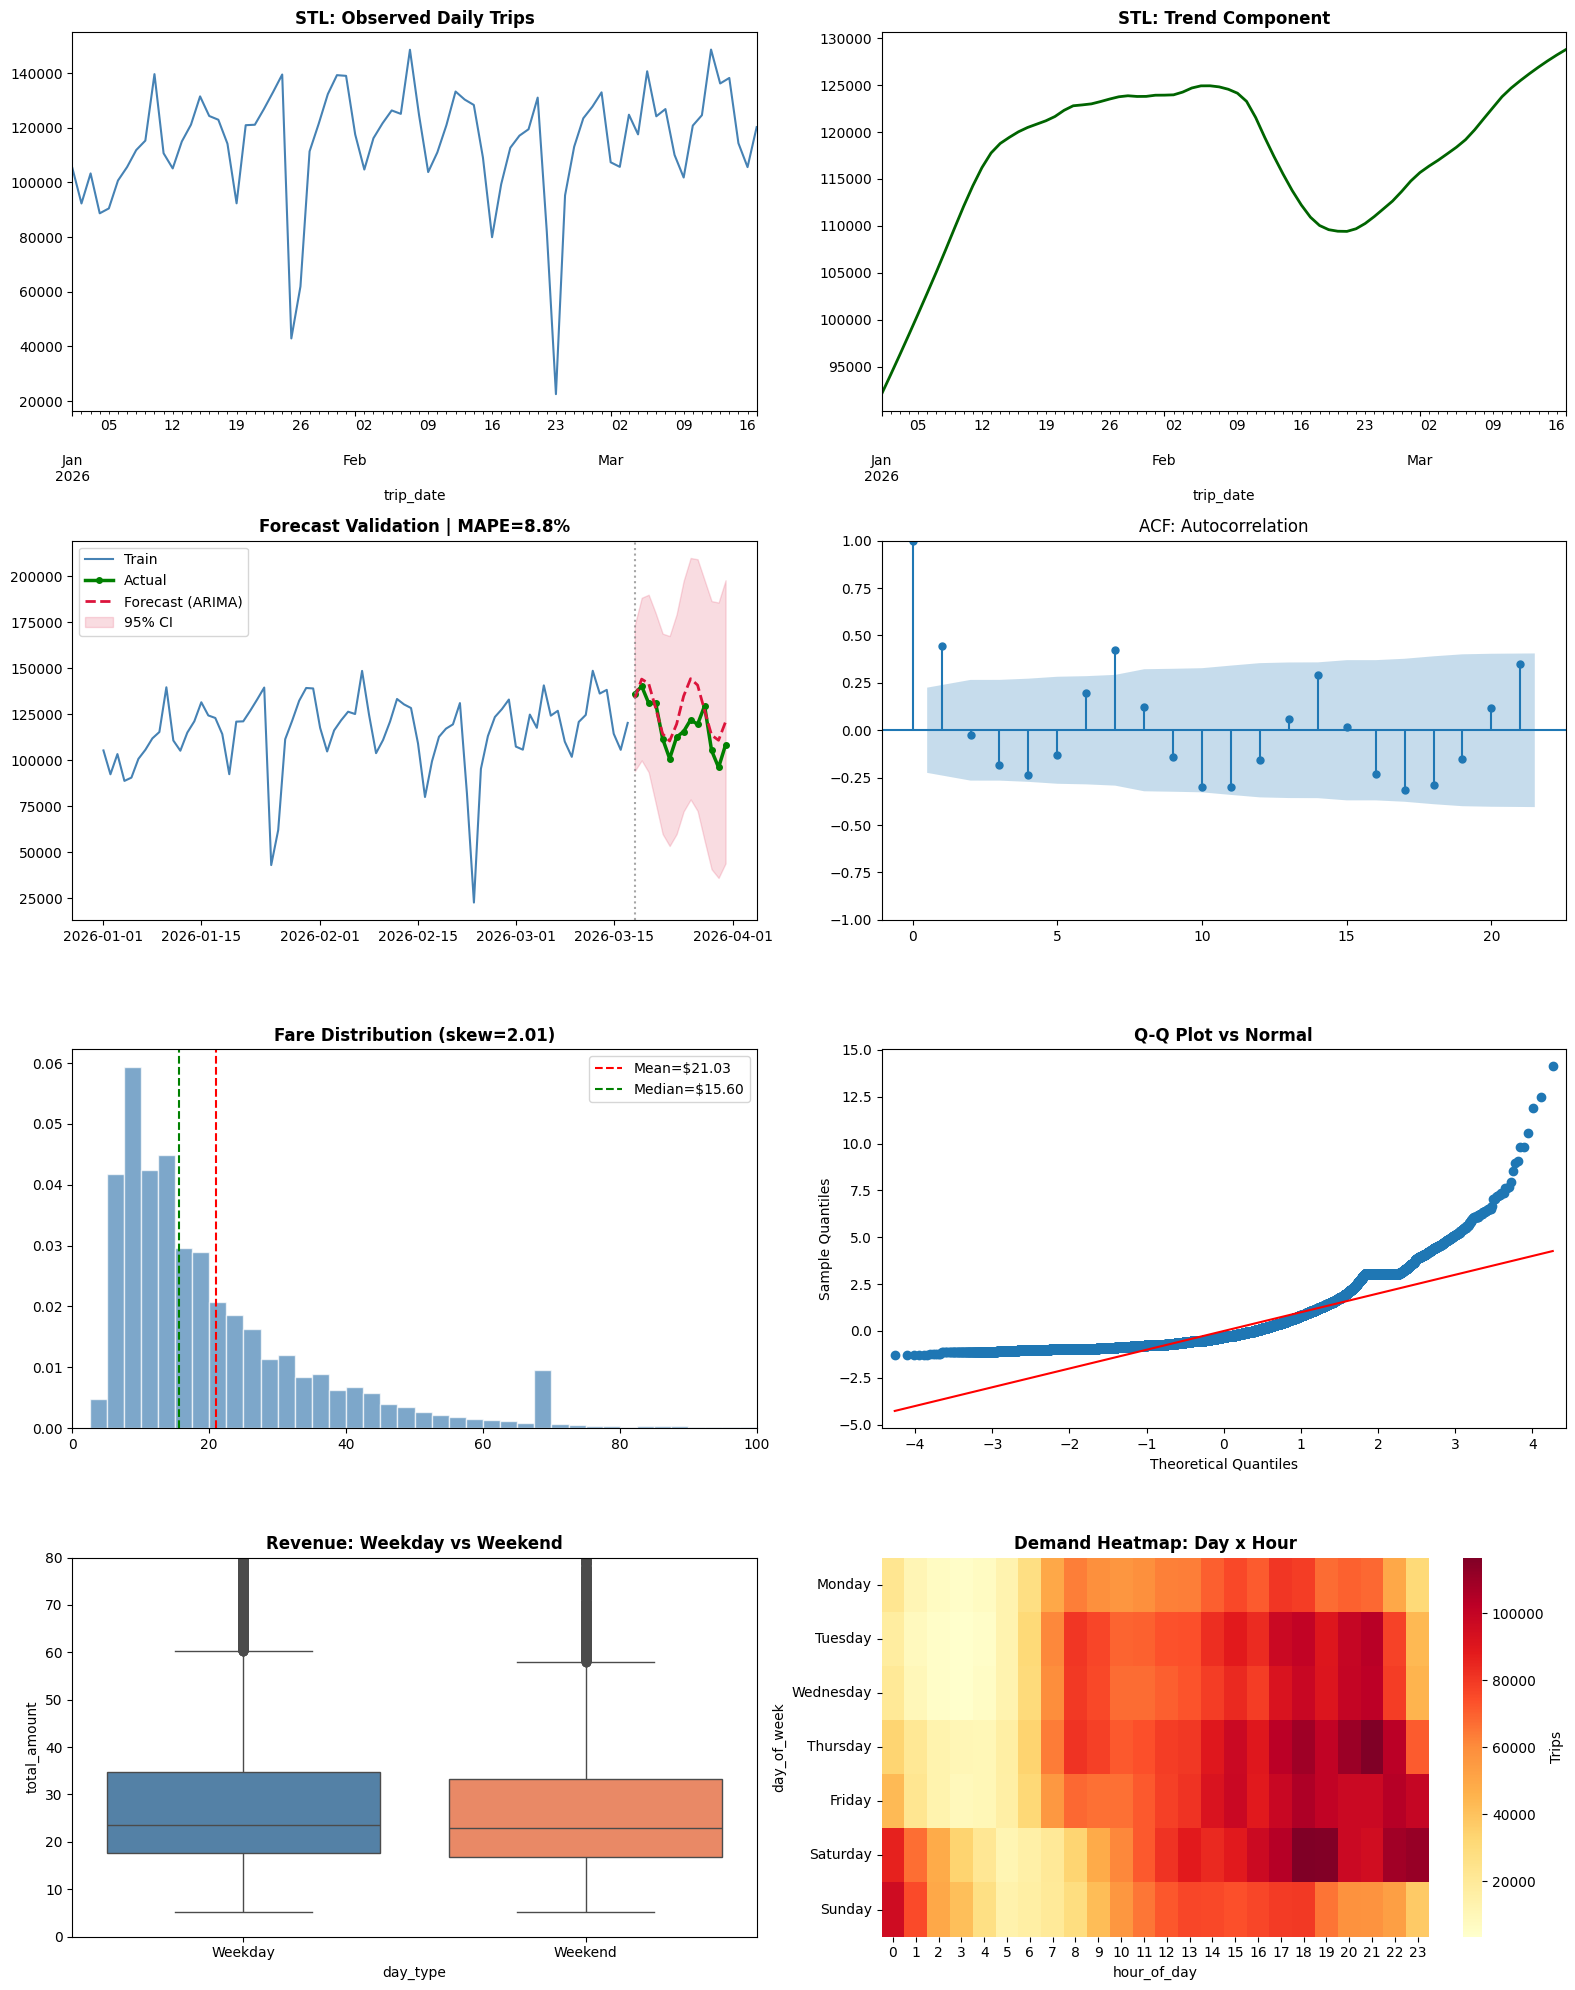

In [25]:
fig = plt.figure(figsize=(16, 20))

ax1 = plt.subplot(4, 2, 1)
stl_result.observed.plot(ax=ax1, color='steelblue', linewidth=1.5)
ax1.set_title('STL: Observed Daily Trips', fontweight='bold')

ax2 = plt.subplot(4, 2, 2)
stl_result.trend.plot(ax=ax2, color='darkgreen', linewidth=2)
ax2.set_title('STL: Trend Component', fontweight='bold')

ax3 = plt.subplot(4, 2, 3)
ax3.plot(train.index, train, label='Train', color='steelblue', linewidth=1.5)
ax3.plot(test.index, test, label='Actual', color='green', linewidth=2.5, marker='o', markersize=4)
ax3.plot(test.index, forecast_mean, label=f'Forecast ({winner})', color='crimson', linestyle='--', linewidth=2)
ax3.fill_between(test.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='crimson', alpha=0.15, label='95% CI')
ax3.axvline(x=test.index[0], color='gray', linestyle=':', alpha=0.7)
ax3.set_title(f'Forecast Validation | MAPE={mape:.1f}%', fontweight='bold')
ax3.legend()

ax4 = plt.subplot(4, 2, 4)
plot_acf(train, lags=21, ax=ax4, title='ACF: Autocorrelation')

ax5 = plt.subplot(4, 2, 5)
ax5.hist(fare_sample, bins=100, color='steelblue', edgecolor='white', alpha=0.7, density=True)
ax5.axvline(fare_sample.mean(), color='red', linestyle='--', label=f'Mean=${fare_sample.mean():.2f}')
ax5.axvline(fare_sample.median(), color='green', linestyle='--', label=f'Median=${fare_sample.median():.2f}')
ax5.set_title(f'Fare Distribution (skew={skewness:.2f})', fontweight='bold')
ax5.legend()
ax5.set_xlim(0, 100)

ax6 = plt.subplot(4, 2, 6)
qqplot(fare_sample, line='s', ax=ax6, fit=True)
ax6.set_title('Q-Q Plot vs Normal', fontweight='bold')

ax7 = plt.subplot(4, 2, 7)
sample_df = df.sample(min(50000, len(df)), random_state=SEED)
sns.boxplot(data=sample_df, x='day_type', y='total_amount', ax=ax7, palette=['steelblue', 'coral'])
ax7.set_title('Revenue: Weekday vs Weekend', fontweight='bold')
ax7.set_ylim(0, 80)

ax8 = plt.subplot(4, 2, 8)
hourly = df.groupby(['day_of_week', 'hour_of_day']).size().reset_index(name='count')
hourly_pivot = hourly.pivot(index='day_of_week', columns='hour_of_day', values='count')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_pivot = hourly_pivot.reindex([d for d in day_order if d in hourly_pivot.index])
sns.heatmap(hourly_pivot, cmap='YlOrRd', ax=ax8, cbar_kws={'label': 'Trips'})
ax8.set_title('Demand Heatmap: Day x Hour', fontweight='bold')

plt.tight_layout()
plt.show()
